# ***MODEL BUILDING***

This notebook is to create and test the ML Model we will be building for our cleaned dataset

### **Importing libraries**

Firstly we will import the necessary libraries for this part of the project

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import pickle

### **Importing dataset**

Lets import the cleaned dataset in which we had applied data preprocessing

In [2]:
df = pd.read_csv("cleaned_sales_data.csv")

In [3]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,DiscountedPrice,SellThroughRate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632


In [4]:
df.columns.tolist()

['Date',
 'Store ID',
 'Product ID',
 'Category',
 'Region',
 'Inventory Level',
 'Units Sold',
 'Units Ordered',
 'Price',
 'Discount',
 'Weather Condition',
 'Promotion',
 'Competitor Pricing',
 'Seasonality',
 'Epidemic',
 'Demand',
 'Year',
 'Month',
 'Day',
 'Weekday',
 'DiscountedPrice',
 'SellThroughRate']

### **Feature Selection**

Now lets select the important `features` from our dataset which will help make the model accurate

In [9]:
features = [
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"
]

In [10]:
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

### **Model Building**

Now lets define our target variable and feature list

In [59]:
target = "Demand"

For our features, we will remove the `Date` as we have already extracted relevant information out of it along with the `Units Sold`, `SellThroughRate` and `Units Ordered` which might leak some information about the demand making the model less accurate

In [81]:
features = [
    'Store ID', 
    'Product ID', 
    'Category', 
    'Region',
    'Price', 
    'Discount', 
    'DiscountedPrice', 
    'Promotion', 
    'Weather Condition', 
    'Competitor Pricing', 
    'Seasonality', 
    'Epidemic',
    'Year',
    'Month',
    'Day',
    'Weekday'
]

Now we will be importing relevant libraries for a `catboost` model

In [55]:
import pandas as pd
import numpy as np

from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

Now let us proceed with the training and testing split

In [82]:
X = df[features]
y = df[target]

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

Now we will have to specify the categorical features for `catboost` to work

In [84]:
categorical_cols = [
    'Store ID', 
    'Product ID', 
    'Category', 
    'Region', 
    'Weather Condition', 
    'Promotion', 
    'Seasonality', 
    'Epidemic',
    'Weekday'
]

Now lets train the Regression model on our data

In [85]:
model = CatBoostRegressor(
    iterations = 500,
    learning_rate = 0.05,
    depth = 6,
    eval_metric = "RMSE",
    verbose = 100
)

In [86]:
model.fit(
    X_train, y_train,
    cat_features = categorical_cols,
    eval_set = (X_test, y_test)
)

0:	learn: 46.0006601	test: 46.0381203	best: 46.0381203 (0)	total: 82.6ms	remaining: 41.2s
100:	learn: 30.1183793	test: 29.9070215	best: 29.9070215 (100)	total: 21.7s	remaining: 1m 25s
200:	learn: 25.8474265	test: 25.6513327	best: 25.6513327 (200)	total: 41s	remaining: 1m 1s
300:	learn: 22.5378540	test: 22.4012729	best: 22.4012729 (300)	total: 57.5s	remaining: 38s
400:	learn: 19.9120297	test: 19.8328901	best: 19.8328901 (400)	total: 1m 12s	remaining: 17.9s
499:	learn: 17.5878487	test: 17.5348110	best: 17.5348110 (499)	total: 1m 26s	remaining: 0us

bestTest = 17.53481099
bestIteration = 499



CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=100)

Now lets `predict` and then find evaluation metrics

In [87]:
y_pred = model.predict(X_test)

In [88]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

In [108]:
print(f"CatBoost RMSE: {rmse:.2f}")
print(f"CatBoost MAE: {mae:.2f}")

CatBoost RMSE: 17.53
CatBoost MAE: 12.84


Now lets check the feature importance of our data

In [90]:
importance = model.get_feature_importance()

In [91]:
feature_names = X.columns

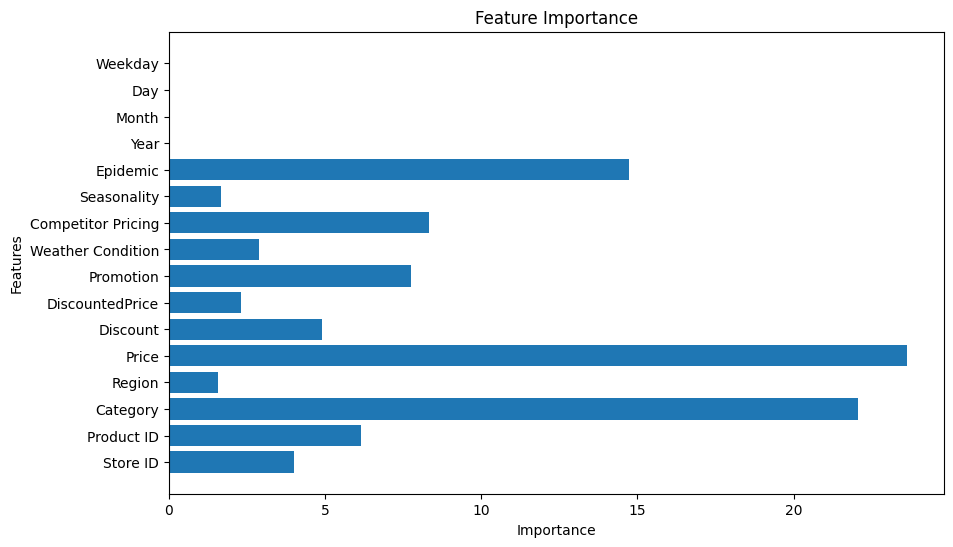

In [92]:
plt.figure(figsize=(10,6))
plt.barh(feature_names, importance)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

Now I will perform some checks to see if the evaluation metrics from our model are well enough

In [93]:
y.mean()

np.float64(104.31715789473684)

In [94]:
y.std()

np.float64(46.96480105784763)

We can see that our target's mean is ~104 and as our MAE was 12.55 we can calculate that our model's prediction is off by ~12% on average

Similarly for RMSE as well it should be ~16%

Now to ensure that our model is genuinely learning from the data and not just making obvious guesses, I will compare it against a naive baseline which is a simple benchmark that predicts the average demand for every observation

The naive baseline represents the worst acceptable performance so any useful model must be able to beat it

In [118]:
baseline_preds = np.full_like(y_test, y_train.mean())
print(f"Baseline MAE: {mean_absolute_error(y_test, baseline_preds)}")

Baseline MAE: 37.01723684210526


As we can see the naive baseline for `MAE` turns out to be ~37.01 which proves that our `CatBoost` model achieves a 59% reduction in `MAE` confirming that it is successfully learning meaningful patterns from the features

#### **Exporting Model**

As the final step of this notebook, I will now export this `CatBoost` model along with the feature list so that it can be further used in our `Streamlit` web UI to allow a user to predict the demand based off on different features 

In [122]:
import joblib
import json

In [121]:
joblib.dump(model, "catboost_model.pkl")

['catboost_model.pkl']

In [123]:
with open('features.json', 'w') as f:
    json.dump(features, f)